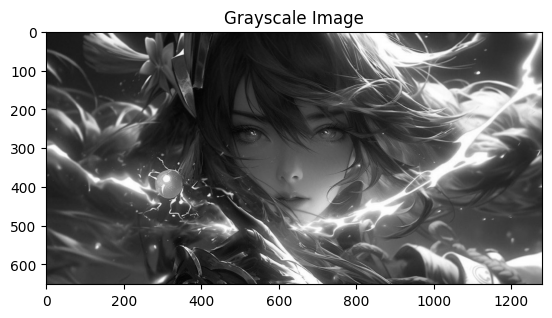

(652, 1280)


In [1]:
import cv2
import matplotlib.pyplot as plt

# Load image
img = cv2.imread(r"C:\Users\dell\OneDrive\Pictures\photo_2024-11-06_18-47-31.jpg", 0)

# Show image
plt.imshow(img, cmap='gray')
plt.title("Grayscale Image")
plt.show()

print(img.shape)

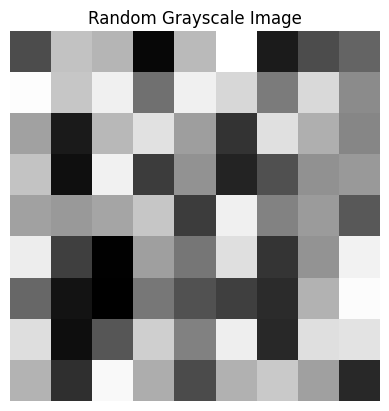

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Generate a 300x300 matrix with random integers between 0 and 255
random_matrix = np.random.randint(0, 256, size=(9, 9), dtype=np.uint8)

# Display the matrix as a grayscale image
plt.imshow(random_matrix, cmap='gray')
plt.title("Random Grayscale Image")
plt.axis('off')  # Hide the pixel grid coordinates
plt.show()


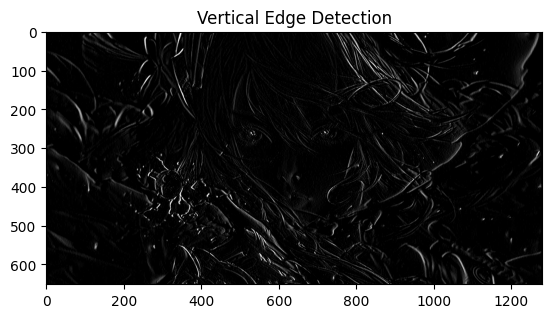

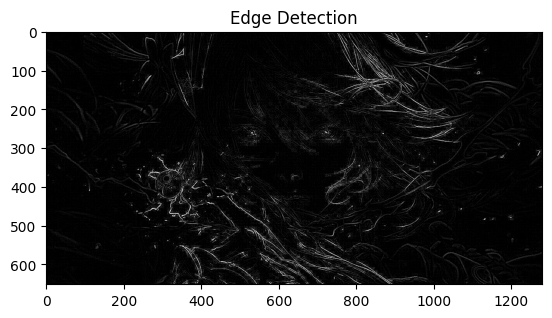

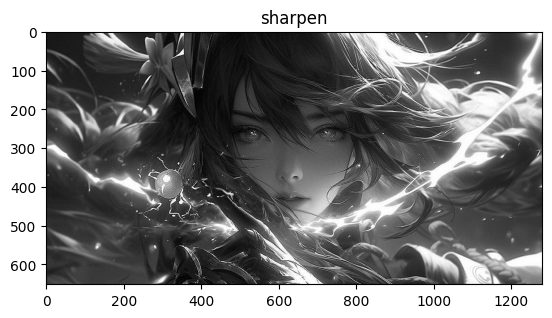

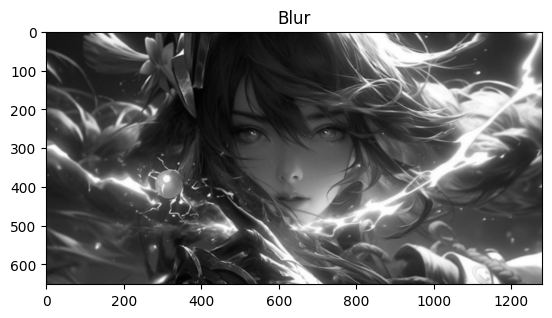

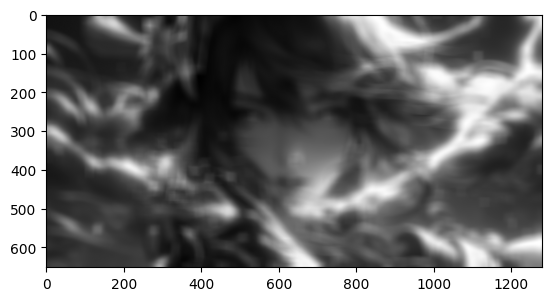

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load grayscale image
img = cv2.imread(r"C:\Users\dell\OneDrive\Pictures\photo_2024-11-06_18-47-31.jpg", 0)

# Edge detection filter(vertical edge)
kernel = np.array([
    [-1, 0, 1],
    [ -1,  0,  1],
    [ -1,  0,  1]
])

# Define your kernel here (example: All Direction Edge Detection)
kernel1 = np.array([[-1, -1, -1],
                   [-1,  8, -1],
                   [-1, -1, -1]])

#sharpen filter
kernel_sharpen = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]])

#blur
kernel_blur = np.array([[1, 1, 1],
                        [1, 1, 1],
                        [1, 1, 1]]) / 9   # Divided by 9 to keep brightness stable


# Apply convolution
output = cv2.filter2D(img, -1, kernel)
output1 = cv2.filter2D(img,-1,kernel1)
output2 = cv2.filter2D(img,-1,kernel_sharpen)
output3 = cv2.filter2D(img,-1,kernel_blur)

# Show result
plt.imshow(output, cmap='gray')
plt.title("Vertical Edge Detection")
plt.show()

plt.imshow(output1, cmap='gray')
plt.title("Edge Detection")
plt.show()

plt.imshow(output2, cmap='gray')
plt.title("sharpen")
plt.show()

plt.imshow(output3, cmap='gray')
plt.title("Blur")
plt.show()

# Create a much larger 25x25 matrix filled with ones
kernel_size = 25
kernel_large_blur = np.ones((kernel_size, kernel_size), np.float32) / (kernel_size * kernel_size)

# Apply the large blur filter
blurred_img = cv2.filter2D(img, -1, kernel_large_blur)

# Display results
plt.imshow(blurred_img, cmap='gray')
plt.show()

[[[[251.]
   [238.]
   [253.]
   [216.]]

  [[195.]
   [239.]
   [159.]
   [223.]]

  [[235.]
   [198.]
   [238.]
   [156.]]

  [[221.]
   [206.]
   [236.]
   [222.]]]]


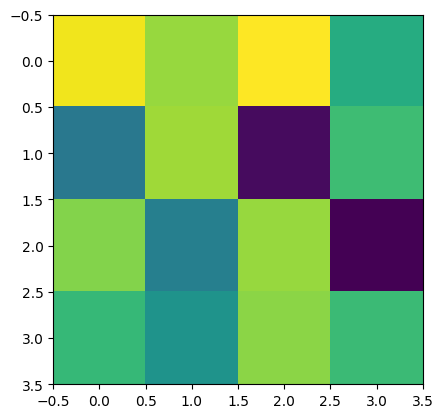

In [4]:
import tensorflow as tf

pool = tf.keras.layers.MaxPooling2D(
    pool_size=(2,2),
    strides=2
)

# 1. Add channel dimension -> shape becomes (300, 300, 1)
img_3d = np.expand_dims(random_matrix, axis=-1)

# 2. Add batch dimension -> shape becomes (1, 300, 300, 1)
img_4d = np.expand_dims(img_3d, axis=0)

# Convert to float32 (TensorFlow prefers float over uint8 for layers)
img_4d = img_4d.astype(np.float32)

img_pooled = pool(img_4d)
print(img_pooled.numpy())

#squeeze back to 2 dimension
squeezed_img = np.squeeze(img_pooled)
plt.imshow(squeezed_img)

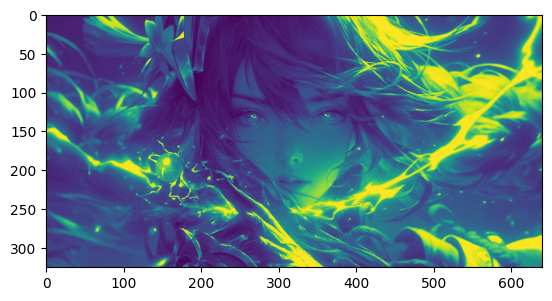

In [5]:
# 1. Add channel dimension -> shape becomes (300, 300, 1)
img_3d = np.expand_dims(img, axis=-1)

# 2. Add batch dimension -> shape becomes (1, 300, 300, 1)
img_4d = np.expand_dims(img_3d, axis=0)

# Convert to float32 (TensorFlow prefers float over uint8 for layers)
img_4d = img_4d.astype(np.float32)

img_pooled = pool(img_4d)

#squeeze back to 2 dimension
squeezed_img = np.squeeze(img_pooled)
plt.imshow(squeezed_img)

In [6]:
#using ReLU = max(0,x)

x = np.array([1,2,-3,5,0,-1,8,6])

ReLUed = tf.keras.activations.relu(x)

print(ReLUed.numpy())

[1 2 0 5 0 0 8 6]


In [7]:
#usng sigmoid = 1/1+e^-x (tensorflow only takes floating values for sigmoid and sigmoid also suffers from vanishing gradient problem)

float_x = np.array([x],dtype=np.float32)
sigm = tf.keras.activations.sigmoid(float_x)

print(sigm.numpy())

[[0.73105854 0.8807971  0.04742587 0.9933072  0.5        0.2689414
  0.99966466 0.99752736]]


In [10]:
#first CNN model

import tensorflow as tf
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist

(x_train,y_train),(x_test,y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [17]:
#normalize for better performance
x_train = x_train / 255.0
x_test = x_test / 255.0

In [19]:
#adding dimensions as poolong requires 4d to operate 
#current (60k,28,28)

x_train = x_train[...,tf.newaxis]
x_test = x_test[...,tf.newaxis]

In [20]:
x_train.shape

(60000, 28, 28, 1)

In [30]:
#MODEL

model = models.Sequential([

    #1st layer
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    #pool
    layers.MaxPooling2D((2,2)),
    #2nd layer
    layers.Conv2D(64,(3,3),activation='relu'),
    #pool
    layers.MaxPooling2D((2,2)),
    #flatten(as fuuly connected layer requires 1D vector rather than a multi_dim feature map)
    layers.Flatten(),
    #dense layer
    layers.Dense(64,activation='relu'),
    #output layer (10 class 0->9)
    layers.Dense(10,activation='softmax')
])

In [33]:
#compilation
model.compile(
    optimizer='adam',
    loss = 'sparse_categorical_crossentropy',
    metrics=['accuracy']
)


In [34]:
# Train model
model.fit(
    x_train,
    y_train,
    epochs=5
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 55s 27ms/step - accuracy: 0.9559 - loss: 0.1479
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9852 - loss: 0.0480
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 84s 27ms/step - accuracy: 0.9895 - loss: 0.0329
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 78s 25ms/step - accuracy: 0.9926 - loss: 0.0236
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 455s 22ms/step - accuracy: 0.9944 - loss: 0.0181


In [35]:
#evaluaton

test_loss, test_acc = model.evaluate(
    x_test,
    y_test
)

print("Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9905 - loss: 0.0299
Accuracy: 0.9904999732971191


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
the digit is  5
the prediction probability is  [[0.00385838 0.00688039 0.00295666 0.03505994 0.00730652 0.84364486
  0.01051771 0.00655471 0.02453356 0.05868727]]


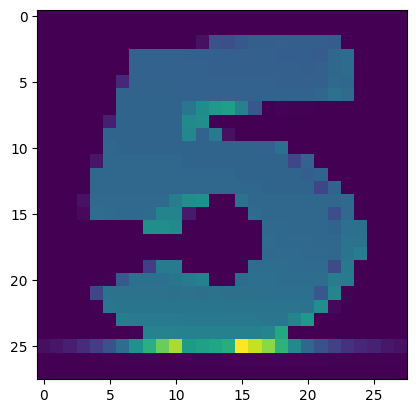

In [46]:
#checking with a rando image from internet

img = cv2.imread(r"C:\Users\dell\Downloads\istockphoto-182196879-612x612.jpg",cv2.IMREAD_GRAYSCALE)

img = 255 - img #very important mnist(black bg white digit) random photos can have diffrent colors accuracy can be terrible without this
img = cv2.resize(img,(28,28))
img = img / 255.0
plt.imshow(img)
img = img.reshape(1,28,28,1)

prediction = model.predict(img)

#convert probability to digit
digit = np.argmax(prediction)

print("the digit is ",digit)
print("the prediction probability is ",prediction)
